In [1]:
# ----------------------------------------------------------------------------
# SEL 1 - Setup Lingkungan & Parameter
# ----------------------------------------------------------------------------
import os, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import cv2
from datasets import load_dataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_H, IMG_W = 32, 128
BATCH_SIZE   = 64
EPOCHS       = 80            
MAX_LEN      = 24
ROT_DEG      = 5
SHEAR        = 0.2
DROPOUT      = 0.2
TIME_STEPS   = 64
OUT_DIR      = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

print("GPU:", tf.config.list_physical_devices('GPU'))
print("[OK] SEL 1 selesai")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
[OK] SEL 1 selesai


In [2]:
# ----------------------------------------------------------------------------
# SEL 2 - Pemuatan Dataset IAM & Charset
# ----------------------------------------------------------------------------
try:
    from kaggle_secrets import UserSecretsClient
    from huggingface_hub import login
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    if hf_token: login(token=hf_token)
except Exception as e:
    print(f"[WARN] Otentikasi HF: {e}")

print("Memuat dataset IAM ...")
ds = load_dataset("priyank-m/IAM_words_text_recognition")
all_split = list(ds.keys())

charset = set()
for sp in all_split:
    texts = ds[sp].to_pandas()["text"].astype(str).tolist()
    for t in texts: charset.update(t)
        
charset = sorted(charset)
char_to_num = {c: i for i, c in enumerate(charset)}
num_to_char = {i: c for i, c in enumerate(charset)}
NUM_CLASSES = len(charset) + 1
BLANK = len(charset)

def encode_label(text):
    return [char_to_num[c] for c in str(text) if c in char_to_num][:MAX_LEN]

print("[OK] SEL 2 selesai")

Memuat dataset IAM ...


dataset_infos.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

data/train-00000-of-00001-bfc7b63751c36a(…):   0%|          | 0.00/695M [00:00<?, ?B/s]

data/test-00000-of-00001-4cae70e6a03872e(…):   0%|          | 0.00/232M [00:00<?, ?B/s]

data/val-00000-of-00001-472467affea948eb(…):   0%|          | 0.00/233M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/69190 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23064 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/23064 [00:00<?, ? examples/s]

[OK] SEL 2 selesai


In [3]:
# ----------------------------------------------------------------------------
# SEL 3 - Perancangan Prapemrosesan Citra
# ----------------------------------------------------------------------------
def preprocess_image(pil_img):
    img = np.array(pil_img.convert("L"))
    h, w = img.shape
    
    scale = IMG_H / h
    new_w = max(1, min(IMG_W, int(round(w * scale))))
    resized = cv2.resize(img, (new_w, IMG_H), interpolation=cv2.INTER_AREA)
    canvas = np.ones((IMG_H, IMG_W), dtype=np.uint8) * 255
    canvas[:, :new_w] = resized
    
    img_norm = canvas.astype(np.float32) / 255.0
    return img_norm

print("[OK] SEL 3 selesai")

[OK] SEL 3 selesai


In [4]:
# ----------------------------------------------------------------------------
# SEL 4 - Perancangan Augmentasi
# Diterapkan secara khusus hanya untuk data latih
# ----------------------------------------------------------------------------
def augment_image(img_2d):
    h, w = img_2d.shape
    
    # 3.5.1 Rotasi
    angle = random.uniform(-ROT_DEG, ROT_DEG)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img_aug = cv2.warpAffine(img_2d, M, (w, h), borderValue=0.0)
    
    # Kemiringan (Shear)
    s = random.uniform(-SHEAR, SHEAR)
    Msh = np.float32([[1, s, 0], [0, 1, 0]])
    img_aug = cv2.warpAffine(img_aug, Msh, (w, h), borderValue=0.0)
    
    return img_aug

print("[OK] SEL 4 selesai")

[OK] SEL 4 selesai


In [5]:
# ----------------------------------------------------------------------------
# SEL 5 - Pembuatan Generator & DataLoader
# Menggabungkan Prapemrosesan dan Augmentasi
# ----------------------------------------------------------------------------
pairs = [(sp, i) for sp in all_split for i in range(len(ds[sp]))]
random.shuffle(pairs)
N = len(pairs)
n_train = int(0.60 * N); n_val = int(0.20 * N)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

def make_generator(pair_list, training=False):
    def gen():
        order = list(range(len(pair_list)))
        if training: random.shuffle(order)
        for k in order:
            sp, i = pair_list[k]
            pil, text = ds[sp][i]['image'], ds[sp][i]['text']
            label = encode_label(text)
            if len(label) == 0 or (2 * len(label) + 1) > TIME_STEPS: continue
            
            # Eksekusi Prapemrosesan
            img = preprocess_image(pil)
            if img.sum() < 1.0: continue 
            
            # Eksekusi Augmentasi (Hanya Training)
            if training: img = augment_image(img)
                
            img = np.expand_dims(img, -1)
            lab = np.array(label + [BLANK] * (MAX_LEN - len(label)), dtype=np.int64)
            yield img, lab, np.int64(len(label))
    return gen

out_sig = (
    tf.TensorSpec(shape=(IMG_H, IMG_W, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(MAX_LEN,), dtype=tf.int64),
    tf.TensorSpec(shape=(), dtype=tf.int64),
)

def to_dataset(pair_list, training=False):
    d = tf.data.Dataset.from_generator(make_generator(pair_list, training), output_signature=out_sig)
    d = d.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    if training: d = d.repeat()
    return d

train_ds = to_dataset(train_pairs, training=True)
val_ds   = to_dataset(val_pairs,   training=False)
test_ds  = to_dataset(test_pairs,  training=False)

steps_per_epoch  = len(train_pairs) // BATCH_SIZE
validation_steps = max(1, len(val_pairs) // BATCH_SIZE)
print("[OK] SEL 5 selesai")

[OK] SEL 5 selesai


I0000 00:00:1783755478.644706      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783755478.650916      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
# ----------------------------------------------------------------------------
# SEL 6 - Perancangan Lapisan Ekstraksi Fitur (CNN)
# ----------------------------------------------------------------------------
def build_cnn_extractor(inp):
    x = layers.Conv2D(32, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    
    x = layers.MaxPooling2D((2, 2))(x)                   
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    
    x = layers.MaxPooling2D((2, 1))(x)                   
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    
    return x

print("[OK] SEL 6 selesai")

[OK] SEL 6 selesai


In [7]:
# ----------------------------------------------------------------------------
# SEL 7 - Perancangan BiLSTM dan Softmax
# ----------------------------------------------------------------------------
def build_bilstm_classifier(cnn_out):
    # Reshape keluaran CNN menjadi sekuens
    x = layers.Permute((2, 1, 3))(cnn_out)                     
    x = layers.Reshape((TIME_STEPS, 8 * 128))(x)         
    
    #  Pemodelan Sekuensial (BiLSTM)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=DROPOUT))(x)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=DROPOUT))(x)
    
    #  Lapisan Klasifikasi dan Fungsi Softmax
    y = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)
    return y

# Penggabungan Arsitektur Hybrid
inp = layers.Input(shape=(IMG_H, IMG_W, 1), name="image")
cnn_features = build_cnn_extractor(inp)
output = build_bilstm_classifier(cnn_features)
model = tf.keras.Model(inp, output)

print("[OK] SEL 7 selesai")

[OK] SEL 7 selesai


In [8]:
# ----------------------------------------------------------------------------
# SEL 8 - Training Loop dengan Adam & Early Stopping Ketat
# ----------------------------------------------------------------------------
def ctc_loss(y_true, y_pred, label_len):
    batch = tf.shape(y_pred)[0]
    time  = tf.shape(y_pred)[1]
    input_len = tf.fill([batch, 1], time)
    label_len = tf.reshape(label_len, [batch, 1])
    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_len, label_len)
    return tf.reduce_mean(loss)

class CTCModel(tf.keras.Model):
    def __init__(self, base):
        super().__init__()
        self.base = base
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
    @property
    def metrics(self): return [self.loss_tracker]
    def call(self, x, training=False): return self.base(x, training=training)
    def train_step(self, data):
        img, lab, lab_len = data
        with tf.GradientTape() as tape:
            y = self.base(img, training=True)
            loss = ctc_loss(lab, y, lab_len)
        grads = tape.gradient(loss, self.base.trainable_variables)
        grads = [tf.clip_by_norm(g, 5.0) if g is not None else g for g in grads]
        self.optimizer.apply_gradients(zip(grads, self.base.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
    def test_step(self, data):
        img, lab, lab_len = data
        y = self.base(img, training=False)
        loss = ctc_loss(lab, y, lab_len)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

ctc_model = CTCModel(model)
ctc_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

# Perancangan Early Stopping yang Lebih Stabil
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("Memulai training ...")
history = ctc_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks
)
print("[OK] SEL 8 selesai")

Memulai training ...
Epoch 1/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 189s 161ms/step - loss: 10.2112 - val_loss: 15.7400 - learning_rate: 0.0010
Epoch 2/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 175s 161ms/step - loss: 4.1286 - val_loss: 6.1294 - learning_rate: 0.0010
Epoch 3/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 174s 161ms/step - loss: 2.8794 - val_loss: 5.9753 - learning_rate: 0.0010
Epoch 4/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 175s 161ms/step - loss: 2.4115 - val_loss: 4.6642 - learning_rate: 0.0010
Epoch 5/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 175s 162ms/step - loss: 2.1084 - val_loss: 4.2539 - learning_rate: 0.0010
Epoch 6/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 174s 161ms/step - loss: 1.9154 - val_loss: 2.6182 - learning_rate: 0.0010
Epoch 7/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 174s 161ms/step - loss: 1.7521 - val_loss: 2.2973 - learning_rate: 0.0010
Epoch 8/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 173s 160ms/step - loss: 1.6182 - val_loss: 3.1496 - learning_rate: 0.0010
Epoch 9/80
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 172s 15

In [9]:
# ----------------------------------------------------------------------------
# SEL 9 - Evaluasi Model 
# ----------------------------------------------------------------------------
def decode_batch_greedy(y_pred):
    input_len = np.ones(y_pred.shape[0]) * y_pred.shape[1]
    
    res, _ = tf.keras.backend.ctc_decode(
        y_pred, input_length=input_len, 
        greedy=True
    )
    out = res[0].numpy()
    return ["".join(num_to_char.get(int(i), "") for i in seq if int(i) >= 0 and int(i) != BLANK) for seq in out]

def levenshtein(a, b):
    m, n = len(a), len(b)
    d = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): d[i][0] = i
    for j in range(n+1): d[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            d[i][j] = min(d[i-1][j]+1, d[i][j-1]+1, d[i-1][j-1]+cost)
    return d[m][n]

def evaluate(dataset):
    cn = cd = wn = wd = 0
    for img, lab, lab_len in dataset:
        y = model(img, training=False).numpy()
        preds = decode_batch_greedy(y)
        labn = lab.numpy(); lln = lab_len.numpy()
        for k in range(len(preds)):
            true_seq = labn[k][:int(lln[k])]
            gt = "".join(num_to_char.get(int(i), "") for i in true_seq if int(i) != BLANK)
            pr = preds[k]
            cn += levenshtein(gt, pr); cd += max(1, len(gt))
            wn += 0 if gt == pr else 1; wd += 1
    return cn/cd*100, wn/wd*100

print("Mengevaluasi data uji :")
cer, wer = evaluate(test_ds)

print(f"\n=========== HASIL AKHIR ===========")
print(f"  CER              : {cer:.2f} %")
print(f"  WER              : {wer:.2f} %")
print(f"  Akurasi Karakter : {100-cer:.2f} %")
print(f"  Akurasi Kata     : {100-wer:.2f} %")
print("===================================")
print("[OK] SEL 9 selesai")

Mengevaluasi data uji :

=========== HASIL AKHIR ===========
  CER              : 7.87 %
  WER              : 21.03 %
  Akurasi Karakter : 92.13 %
  Akurasi Kata     : 78.97 %
[OK] SEL 9 selesai


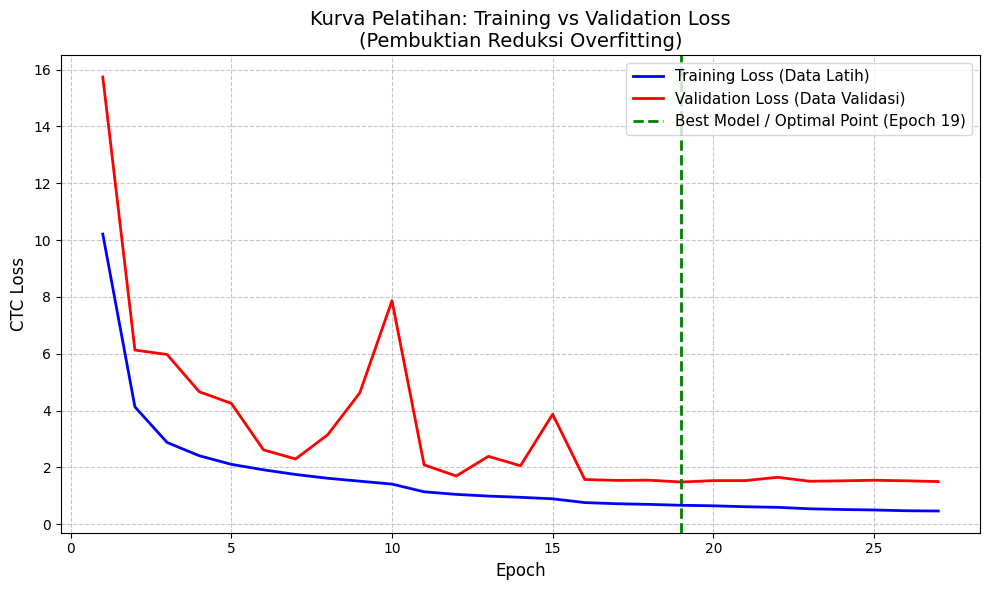

[OK] SEL 10 selesai


In [10]:
# ----------------------------------------------------------------------------
# SEL 10 - Visualisasi Grafik Pelatihan (Mendeteksi Overfitting)
# ----------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Mengambil data loss dari histori pelatihan
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_loss, 'b-', linewidth=2, label='Training Loss (Data Latih)')
plt.plot(epochs_range, val_loss, 'r-', linewidth=2, label='Validation Loss (Data Validasi)')

# Menandai titik Early Stopping (Epoch 22 yang menjadi Best Epoch)
best_epoch = np.argmin(val_loss) + 1
plt.axvline(x=best_epoch, color='g', linestyle='--', linewidth=2, 
            label=f'Best Model / Optimal Point (Epoch {best_epoch})')

plt.title('Kurva Pelatihan: Training vs Validation Loss\n(Pembuktian Reduksi Overfitting)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('CTC Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/grafik_loss_overfitting.png", dpi=150)
plt.show()

print("[OK] SEL 10 selesai")

In [11]:
# ----------------------------------------------------------------------------
# SEL 11 - Analisis Mendalam Levenshtein Distance (S, I, D)
# ----------------------------------------------------------------------------
def levenshtein_detailed(a, b):
    m, n = len(a), len(b)
    d = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): d[i][0] = i
    for j in range(n + 1): d[0][j] = j
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            d[i][j] = min(d[i - 1][j] + 1,      # Deletion
                          d[i][j - 1] + 1,      # Insertion
                          d[i - 1][j - 1] + cost) # Substitution
            
    # Melakukan penelusuran balik (backtracking) untuk mencari nilai S, I, dan D
    i, j = m, n
    s_cnt = i_cnt = d_cnt = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and a[i - 1] == b[j - 1]:
            i -= 1; j -= 1
        elif i > 0 and j > 0 and d[i][j] == d[i - 1][j - 1] + 1:
            s_cnt += 1; i -= 1; j -= 1
        elif i > 0 and d[i][j] == d[i - 1][j] + 1:
            d_cnt += 1; i -= 1
        elif j > 0 and d[i][j] == d[i][j - 1] + 1:
            i_cnt += 1; j -= 1
            
    return s_cnt, i_cnt, d_cnt

def detailed_evaluation(dataset):
    total_chars = 0
    total_S, total_I, total_D = 0, 0, 0
    failed_cases = [] # Menyimpan contoh prediksi yang salah
    
    for img, lab, lab_len in dataset:
        y = model(img, training=False).numpy()
        preds = decode_batch_greedy(y)
        labn = lab.numpy(); lln = lab_len.numpy()
        
        for k in range(len(preds)):
            true_seq = labn[k][:int(lln[k])]
            gt = "".join(num_to_char.get(int(i), "") for i in true_seq if int(i) != BLANK)
            pr = preds[k]
            
            s, i_cnt, d = levenshtein_detailed(gt, pr)
            total_S += s; total_I += i_cnt; total_D += d
            total_chars += len(gt)
            
            # Menyimpan 5 contoh kata yang salah ditebak untuk dianalisis
            if gt != pr and len(failed_cases) < 5:
                failed_cases.append({'Asli': gt, 'Prediksi': pr, 'S': s, 'I': i_cnt, 'D': d})
                
    return total_S, total_I, total_D, total_chars, failed_cases

print("Membedah komposisi kesalahan prediksi pada data uji...")
S, I, D, N_total, failures = detailed_evaluation(test_ds)

print("\n=========== ANALISIS LEVENSHTEIN DISTANCE ===========")
print(f"Total Karakter Asli (N) : {N_total}")
print(f"Total Substitusi (S)    : {S} karakter (Salah baca)")
print(f"Total Insersi (I)       : {I} karakter (Penambahan liar)")
print(f"Total Delesi (D)        : {D} karakter (Karakter terlewat)")
print(f"Total Kesalahan (S+I+D) : {S + I + D}")
print(f"Kalkulasi CER Akhir     : {((S + I + D) / N_total) * 100:.2f} %")
print("=====================================================")

print("\n[CONTOH KASUS SALAH BACA UNTUK BAB 4]")
for idx, case in enumerate(failures):
    print(f"{idx+1}. Asli: '{case['Asli']}' | Prediksi: '{case['Prediksi']}' -> (S:{case['S']}, I:{case['I']}, D:{case['D']})")

print("[OK] SEL 11 selesai")

Membedah komposisi kesalahan prediksi pada data uji...

=========== ANALISIS LEVENSHTEIN DISTANCE ===========
Total Karakter Asli (N) : 95526
Total Substitusi (S)    : 5162 karakter (Salah baca)
Total Insersi (I)       : 1042 karakter (Penambahan liar)
Total Delesi (D)        : 1316 karakter (Karakter terlewat)
Total Kesalahan (S+I+D) : 7520
Kalkulasi CER Akhir     : 7.87 %

[CONTOH KASUS SALAH BACA UNTUK BAB 4]
1. Asli: 'United' | Prediksi: 'Uniced' -> (S:1, I:0, D:0)
2. Asli: 'means' | Prediksi: 'mens' -> (S:0, I:0, D:1)
3. Asli: 'the' | Prediksi: 'mth' -> (S:0, I:1, D:1)
4. Asli: 'yet' | Prediksi: '.' -> (S:1, I:0, D:2)
5. Asli: ',' | Prediksi: 'I' -> (S:1, I:0, D:0)
[OK] SEL 11 selesai


[*] Berhasil menemukan sampel tulisan bersambung pada index 3.
[*] Kata yang diproses: 'endeavour'


I0000 00:00:1783760320.231467     100 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


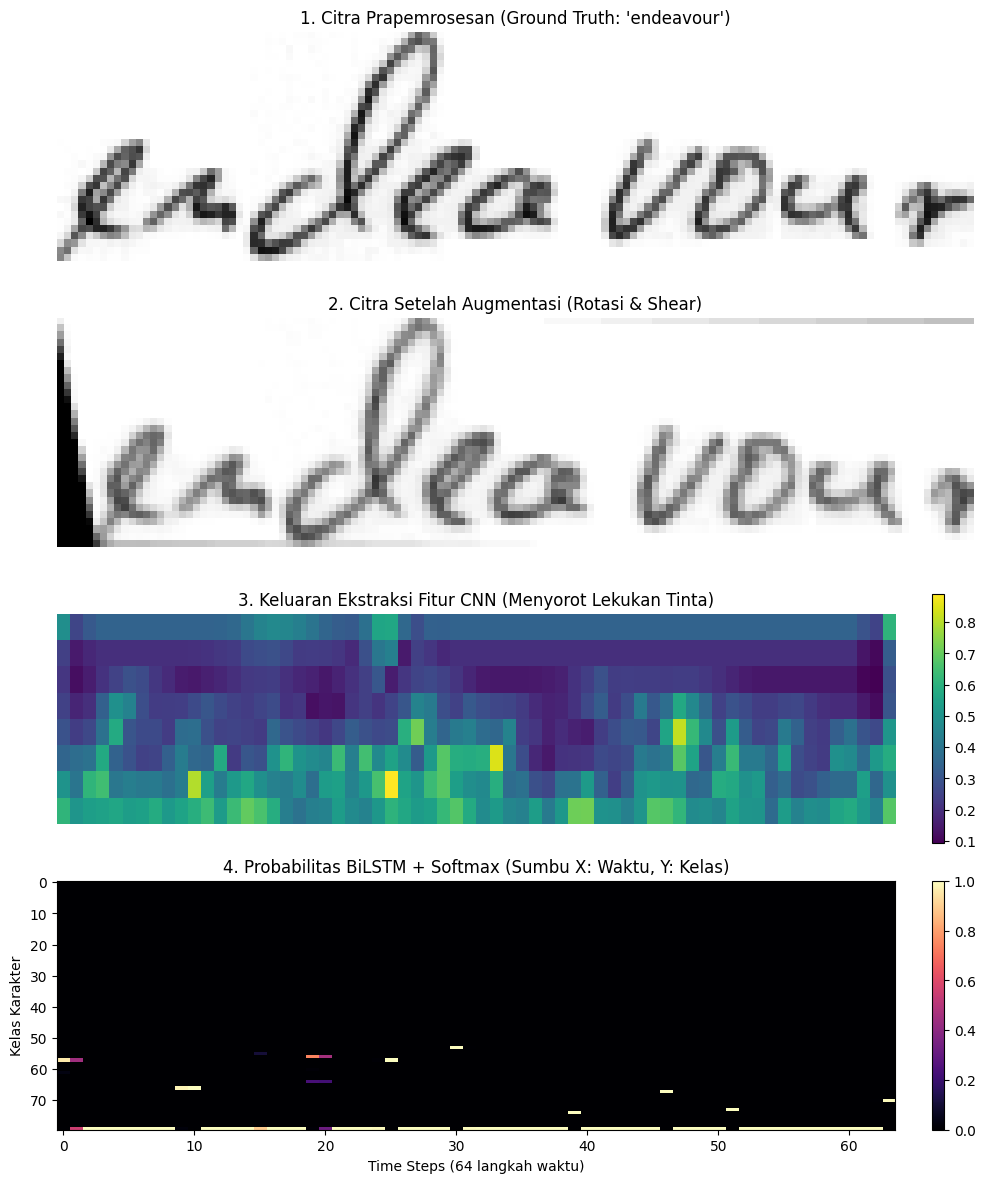

[OK] SEL 12 selesai


In [12]:
# ----------------------------------------------------------------------------
# SEL 12 (REVISI) - Visualisasi Alur Proses (Wajib Tulisan Bersambung)
# ----------------------------------------------------------------------------
import matplotlib.pyplot as plt

# 1. Mencari sampel tulisan bersambung di data uji
# Heuristik: Kata >= 7 huruf dan huruf kecil semua biasanya ditulis bersambung di IAM
sp = 'test' if 'test' in all_split else all_split[-1]
sample_idx = 0
for i in range(len(ds[sp])):
    text = str(ds[sp][i]['text'])
    if len(text) >= 8 and text.isalpha() and text.islower():
        sample_idx = i
        break # Berhenti mencari jika sudah menemukan kata yang pas

pil_img = ds[sp][sample_idx]['image']
gt_text = ds[sp][sample_idx]['text']

print(f"[*] Berhasil menemukan sampel tulisan bersambung pada index {sample_idx}.")
print(f"[*] Kata yang diproses: '{gt_text}'")

# 2. Prapemrosesan & Augmentasi
img_norm = preprocess_image(pil_img) 
img_aug = augment_image(img_norm)    

# 3. Prediksi Model (Ambil fitur CNN & Output Akhir)
img_input = np.expand_dims(img_norm, axis=(0, -1)) 

cnn_layer = [l for l in model.layers if isinstance(l, layers.MaxPooling2D)][-1]
cnn_extractor = tf.keras.Model(inputs=model.input, outputs=cnn_layer.output)

cnn_out = cnn_extractor.predict(img_input, verbose=0)[0]  
softmax_out = model.predict(img_input, verbose=0)[0]      
cnn_heatmap = np.mean(cnn_out, axis=-1)

# 4. Proses Visualisasi (4 Baris Panel)
fig, axes = plt.subplots(4, 1, figsize=(10, 12))

# PANEL A
axes[0].imshow(img_norm, cmap='gray')
axes[0].set_title(f"1. Citra Prapemrosesan (Ground Truth: '{gt_text}')")
axes[0].axis('off')

# PANEL B
axes[1].imshow(img_aug, cmap='gray')
axes[1].set_title("2. Citra Setelah Augmentasi (Rotasi & Shear)")
axes[1].axis('off')

# PANEL C
cnn_heatmap_resized = cv2.resize(cnn_heatmap, (128, 32), interpolation=cv2.INTER_NEAREST)
im = axes[2].imshow(cnn_heatmap_resized, cmap='viridis')
axes[2].set_title("3. Keluaran Ekstraksi Fitur CNN (Menyorot Lekukan Tinta)")
axes[2].axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

# PANEL D
im2 = axes[3].imshow(softmax_out.T, cmap='magma', aspect='auto')
axes[3].set_title("4. Probabilitas BiLSTM + Softmax (Sumbu X: Waktu, Y: Kelas)")
axes[3].set_xlabel("Time Steps (64 langkah waktu)")
axes[3].set_ylabel("Kelas Karakter")
fig.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/visualisasi_bersambung.png", dpi=150)
plt.show()

print("[OK] SEL 12 selesai")

In [13]:
# ----------------------------------------------------------------------------
# SEL 13 - Ekspor dan Simpan Model Terbaik
# ----------------------------------------------------------------------------

model_path = f"{OUT_DIR}/model_skripsi_final.h5"
model.save(model_path)

print(f"[*] Model berhasil disimpan di: {model_path}")
print("[*] Silakan cek menu 'Output' di Kaggle dan UNDUH file .h5 tersebut.")

[*] Model berhasil disimpan di: /kaggle/working/model_skripsi_final.h5
[*] Silakan cek menu 'Output' di Kaggle dan UNDUH file .h5 tersebut.


Menghitung Akurasi Karakter pada Data Latih (Pengambilan Sampel)...
Menghitung Akurasi Karakter pada Data Uji...


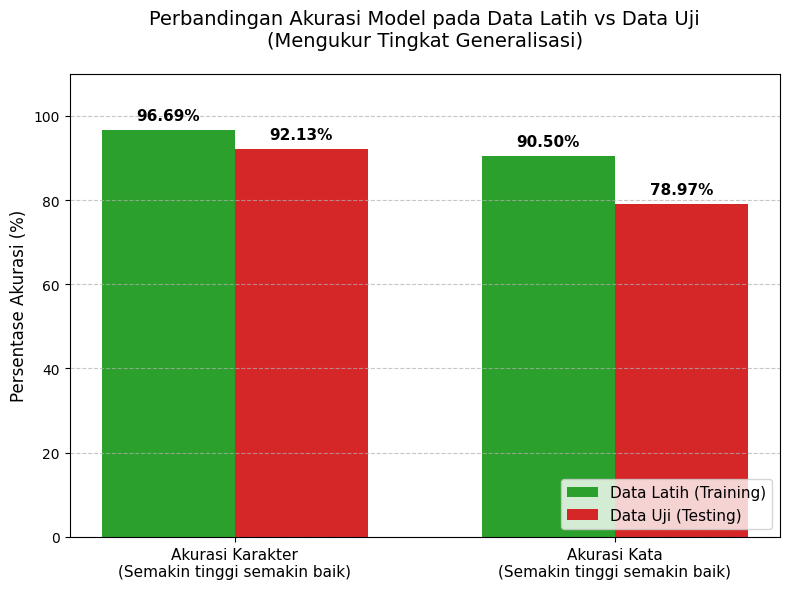

[OK] SEL 14 selesai


In [14]:
# ----------------------------------------------------------------------------
# SEL 14 - Visualisasi Perbandingan Akurasi (Data Latih vs Data Uji)
# ----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

print("Menghitung Akurasi Karakter pada Data Latih (Pengambilan Sampel)...")
# Kita ambil sebagian subset data latih (misal 50 batch) agar tidak menunggu terlalu lama
# Hasilnya sudah sangat representatif untuk mewakili akurasi training
train_subset = train_ds.take(50) 
cer_train, wer_train = evaluate(train_subset)
acc_char_train = 100 - cer_train
acc_word_train = 100 - wer_train

print("Menghitung Akurasi Karakter pada Data Uji...")
# Menggunakan hasil dari SEL 9 sebelumnya (Atau dievaluasi ulang jika butuh)
cer_test, wer_test = evaluate(test_ds)
acc_char_test = 100 - cer_test
acc_word_test = 100 - wer_test

# Siapkan data untuk grafik
labels = ['Akurasi Karakter\n(Semakin tinggi semakin baik)', 'Akurasi Kata\n(Semakin tinggi semakin baik)']
train_scores = [acc_char_train, acc_word_train]
test_scores = [acc_char_test, acc_word_test]

x = np.arange(len(labels))
width = 0.35

# Pembuatan Grafik Batang (Bar Chart)
fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, train_scores, width, label='Data Latih (Training)', color='#2ca02c')
rects2 = ax.bar(x + width/2, test_scores, width, label='Data Uji (Testing)', color='#d62728')

# Kostumisasi Tampilan
ax.set_ylabel('Persentase Akurasi (%)', fontsize=12)
ax.set_title('Perbandingan Akurasi Model pada Data Latih vs Data Uji\n(Mengukur Tingkat Generalisasi)', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 110) # Set batas atas sedikit lebih dari 100 untuk memberi ruang teks
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Fungsi untuk menambahkan teks angka di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 poin offset vertikal
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/grafik_akurasi_latih_vs_uji.png", dpi=150)
plt.show()

print("[OK] SEL 14 selesai")